In [1]:
import numpy as np
import pandas as pd
import cvxpy as cp
import seaborn as sns
import mosek
import matplotlib.pyplot as plt
import datetime as date
from datetime import datetime as dt
from dateutil.relativedelta import *
import scipy.stats
from scipy.stats import rankdata
import distortion_function as hf
import phi_divergence as phi
import affine_approx as af
import Utility_functions as ut
import Cutting_plane as ct
from time import process_time
import Hit_and_Run as hr
import itertools as itertools

In [2]:
import importlib
importlib.reload(ct)
importlib.reload(ut)
importlib.reload(af)
importlib.reload(hr)
importlib.reload(hf)

<module 'distortion_function' from 'C:\\Users\\gjin\\Robust\\distortion_function.py'>

In [3]:
def ranktoset (A):
    A = list(A)
    sets = [[A[0]]]
    for i in range(1,len(A)):
        new = A[0:i+1]
        sets.append(new)
    return(sets)

In [4]:
d = np.array([4,8,10])
#p = np.array([0.375,0.375,0.25])
#par_mnews=np.array([[6,4,2,4]])
#m = 3
p_items = np.array([[0.375,0.375,0.25],[0.25,0.25,0.5],[0.127,0.786,0.087]])
par_mnews = np.array([[6,4,2,4],[8,3,5,2.5],[5,4,1.5,4]])
m = len(d)**len(p_items)
N = 100
par = 2
phi_dot = 1
r = phi_dot/(2*N)*scipy.stats.chi2.ppf(0.95, m)
phi_conj = phi.kb_conj
h_conj = hf.h_spw_conj
phi_func = phi.kb_cut
h_func = hf.h_spw_cut
h_eva = hf.h_spw_eva
eps = 0.0001

In [5]:
indices = np.asarray(list((itertools.product((0, 1, 2), repeat = 3))))
p = np.zeros(m)
for i in range(m):
    p[i] = np.prod(p_items[np.arange(len(p_items)),indices[i]])

In [6]:
def r_obj(d,y,par_news):
    [v_news, l_news, s_news, c_news] = par_news
    return((s_news-v_news)*cp.pos(y-d)-l_news*cp.pos(d-y)+(v_news-c_news)*y)

In [7]:
def mnews_affine_riskmin(p,d,r,indices,par_mnews,phi_conj,slope,const):
    N = len(p)
    I = len(par_mnews)
    K = len(slope)
    lbda = cp.Variable((N,K), nonneg = True)
    y = cp.Variable(I, nonneg = True)
    v = cp.Variable(K, nonneg = True)
    alpha = cp.Variable(1)
    beta = cp.Variable(1)
    gamma = cp.Variable(1,nonneg = True)
    t = cp.Variable(N)
    s = cp.Variable(N)
    c = cp.Variable(1)
    w = cp.Variable(N)
    constraints = [y<= np.max(d)]
    for i in range(N):
        r_profit = 0
        for j in range(I):
            r_profit = r_profit + r_obj(d[indices[i][j]],y[j],par_mnews[j])
        if i == 0:
            profit = r_profit
        else:
            profit = cp.hstack((profit, r_profit))
    for i in range(N):
        constraints.append(-profit[i] - cp.sum(lbda[i]) - beta <= 0)
        constraints.append(s[i] == -alpha + lbda[i]@slope)
        constraints.append(lbda[i] <= v)
        constraints = phi_conj(gamma,s[i],t[i],w[i],constraints)
    constraints.append(alpha + beta + gamma * r  + v@const + p@t <= c)
    obj = cp.Minimize(c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(y.value, c.value)


def mnews_rc_riskmin(sets,p,d,r,par,par_mnews,indices,phi_conj, h_conj):
    N, I, M = [len(p), len(par_mnews), len(sets)]
    v = cp.Variable(M)
    lbda = cp.Variable(M, nonneg = True)
    y = cp.Variable(I, nonneg = True)
    alpha, beta = [cp.Variable(1), cp.Variable(1)]
    gamma = cp.Variable(1,nonneg = True)
    t, z, s, w = [cp.Variable(N),cp.Variable(N),cp.Variable(N), cp.Variable(N)]
    c = cp.Variable(1)
    constraints = [y<= np.max(d)]
    for i in range(N):
        r_profit = 0
        for j in range(I):
            r_profit = r_profit + r_obj(d[indices[i][j]],y[j],par_mnews[j])
        if i == 0:
            profit = r_profit
        else:
            profit = cp.hstack((profit, r_profit))
    for i in range(N):
        lbdasum = 0
        vsum = 0
        for j in range(M):
            if i in sets[j]:
                lbdasum = lbdasum + lbda[j]
                vsum = vsum + v[j]
        constraints.append(-profit[i] - lbdasum - beta <= 0)
        constraints.append(s[i] == -alpha + vsum)
        constraints = phi_conj(gamma,s[i],t[i],w[i],constraints)
    constraints = h_conj(lbda,v,z,par,constraints)
    constraints.append(alpha + beta + gamma * r  + cp.sum(z) + p@t <= c)
    obj = cp.Minimize(c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(y.value, c.value)

In [8]:
def r_obj_calc(d,y,par_news):
    [v_news, l_news, s_news, c_news] = par_news
    return((s_news-v_news)*np.maximum(y-d,0)-l_news*np.maximum(d-y,0)+(v_news-c_news)*y)

def robustcheck_riskmin(y,d,r,p,par,par_mnews,indices,h_func, phi_func):
    N = len(p)
    profit_value = np.zeros(N)
    for i in range(N):
        for j in range(len(par_mnews)):
            profit_value[i] = profit_value[i] + r_obj_calc(d[indices[i][j]],y[j],par_mnews[j])
    rank = np.argsort(profit_value)
    sets = ranktoset(rank)
    q_b = cp.Variable(N, nonneg = True)
    q = cp.Variable(N, nonneg=True)
    constraints = [cp.sum(q) == 1, cp.sum(q_b)==1]
    constraints = h_func(q_b,q,rank,par,constraints)
    constraints = phi_func(p,q,r,par,constraints)
    obj = cp.Maximize(-q_b.T @ profit_value)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    return(prob.value,q_b.value,q.value)

In [9]:
def multi_item_riskmin_cut(d,r,p,par,par_mnews,h_eva, phi_func,h_func):
    N = len(p)
    I = len(par_mnews)
    y = cp.Variable(I, nonneg= True)
    c = cp.Variable(1)
    constraints = [y<=np.max(d)]
    h = np.zeros(N)
    iterations = 0
    for i in range(N-1):
        h[i] = h_eva(sum(p[i:N]),par)-h_eva(sum(p[i+1:N]),par)
    h[N-1]=h_eva(p[N-1],par)
    for i in range(N):
        r_profit = 0
        for j in range(I):
            r_profit = r_profit + r_obj(d[indices[i][j]],y[j],par_mnews[j])
        if i == 0:
            profit = r_profit
        else:
            profit = cp.hstack((profit, r_profit))
    constraints.append(-h.T @ profit<= c)
    obj = cp.Minimize(c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    w = y.value
    upperobj = c.value
    nonstop = True
    while nonstop:
        [rbvalue,h] = robustcheck_riskmin(w,d,r,p,par,par_mnews,indices,h_func, phi_func)
        print(rbvalue, c.value, iterations)
        if rbvalue <= c.value:
            return(w, upperobj, iterations)
        constraints.append(-h.T @ profit<= c)
        iterations = iterations + 1
        prob = cp.Problem(obj,constraints)
        prob.solve(solver=cp.MOSEK)
        w = y.value
        upperobj = c.value

In [10]:
x_points = af.affine_approx_hspw(par,eps)

In [11]:
x_points

array([0.        , 0.01953125, 0.0390625 , 0.05974579, 0.08035278,
       0.10014734, 0.11986887, 0.14057041, 0.16112502, 0.18085617,
       0.20044729, 0.22085343, 0.24104957, 0.26041946, 0.27959002,
       0.29942078, 0.31898744, 0.33910202, 0.35889052, 0.37911733,
       0.39895987, 0.41913516, 0.43887269, 0.45884272, 0.47832695,
       0.49900673, 0.51908266, 0.53814683, 0.55853291, 0.57783734,
       0.59819597, 0.61741509, 0.63743464, 0.65776584, 0.67709023,
       0.69787141, 0.71745395, 0.73799786, 0.75718699, 0.7768888 ,
       0.7970235 , 0.8169791 , 0.83666735, 0.85701492, 0.87750051,
       0.89722947, 0.91769565, 0.93737421, 0.95756182, 0.97847238,
       0.99867381, 1.        ])

In [12]:
[slope, const] = af.makepoints(af.sing_pw,x_points,par)

In [13]:
#indices = np.array([[0],[1],[2]])
res_upperrob = mnews_affine_riskmin(p,d,r,indices,par_mnews,phi_conj,slope,const)
print(res_upperrob)

(array([7.99999998, 9.99999995, 7.99999997]), array([-47.96933649]))


In [14]:
profit_value = np.zeros(m)
for i in range(m):
    for j in range(len(par_mnews)):
        profit_value[i] = profit_value[i] + r_obj_calc(d[indices[i][j]],res_upperrob[0][j],par_mnews[j])
rank = np.argsort(profit_value)
sets = ranktoset(rank)
rc_res = mnews_rc_riskmin(sets,p,d,r,par,par_mnews,indices,phi_conj, h_conj)
print(rc_res)

(array([7.99999995, 9.99999999, 8.00000001]), array([-47.96667587]))


In [15]:
multi_item_riskmin_cut(d,r,p,par,par_mnews,h_eva, phi_func,h_func)

ValueError: too many values to unpack (expected 2)

In [16]:
def nominal_risk(y,d,p,par,par_mnews, h_eva):
    N = len(p)
    profit_value = np.zeros(N)
    for i in range(N):
        for j in range(len(par_mnews)):
            profit_value[i] = profit_value[i] + r_obj_calc(d[indices[i][j]],y[j],par_mnews[j])
    rank = np.argsort(profit_value)
    x = profit_value
    q_b = np.zeros(N)
    q_b[rank[0]] = h_eva(p[rank[0]],par)
    risk = -q_b[rank[0]]*x[rank[0]]
    for i in range(1,N):
        q_b[rank[i]] = h_eva(np.sum(p[rank[0:i+1]]),par)-h_eva(np.sum(p[rank[0:i]]),par)
        risk = risk - q_b[rank[i]]*x[rank[i]]
    return(risk, q_b)


def non_robust_mnews_cut(d,p,par,par_mnews, h_eva):
    N = len(p)
    I = len(par_mnews)
    y = cp.Variable(I, nonneg = True)
    c = cp.Variable(1)
    constraints = [y<=np.max(d)]
    h = np.zeros(N)
    iterations = 0
    for i in range(N-1):
        h[i] = h_eva(sum(p[i:N]),par)-h_eva(sum(p[i+1:N]),par)
    h[N-1]=h_eva(p[N-1],par)
    for i in range(N):
        r_profit = 0
        for j in range(I):
            r_profit = r_profit + r_obj(d[indices[i][j]],y[j],par_mnews[j])
        if i == 0:
            profit = r_profit
        else:
            profit = cp.hstack((profit, r_profit))
    constraints.append(-h.T @ profit<= c)
    obj = cp.Minimize(c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    w = y.value
    while True:
        [rbvalue,h] = nominal_risk(w,d,p,par,par_mnews, h_eva)
        #print(rbvalue, c.value)
        if rbvalue <= c.value:
            return(w, c.value, iterations)
        constraints.append(-h.T @ profit<= c)
        iterations = iterations + 1
        prob = cp.Problem(obj,constraints)
        prob.solve(solver=cp.MOSEK)
        w = y.value

        
def non_robust_mnews_uncertain(d,p,par,par_mnews, h_eva):
    N = len(p)
    I = len(par_mnews)
    y = cp.Variable(I, nonneg = True)
    c = cp.Variable(1)
    constraints = [y<=np.max(d)]
    for i in range(N):
        r_profit = 0
        for j in range(I):
            r_profit = r_profit + r_obj(d[indices[i][j]],y[j],par_mnews[j])
        if i == 0:
            profit = r_profit
        else:
            profit = cp.hstack((profit, r_profit))
    constraints.append(-p.T @ profit<= c)
    obj = cp.Maximize(-c)
    prob = cp.Problem(obj,constraints)
    prob.solve(solver=cp.MOSEK)
    w = y.value
    return(w,c.value)


In [17]:
res_nom = non_robust_mnews_cut(d,p,par,par_mnews, h_eva)
print(res_nom)

(array([ 8., 10.,  8.]), array([-56.20036229]), 5)


In [18]:
print(robustcheck_riskmin(res_nom[0],d,r,p,par,par_mnews,indices,h_func, phi_func))
print(robustcheck_riskmin(rc_res[0],d,r,p,par,par_mnews,indices,h_func, phi_func))

(-47.966675689734544, array([0.152435  , 0.08196545, 0.05663162, 0.04603743, 0.01524083,
       0.04472314, 0.01547478, 0.02325411, 0.01794069, 0.02694277,
       0.04578968, 0.00442816, 0.00874357, 0.00930651, 0.00309999,
       0.00195448, 0.00700828, 0.0017074 , 0.04469904, 0.07121559,
       0.1495613 , 0.01261957, 0.02022723, 0.0502388 , 0.01932319,
       0.02115355, 0.04827783]), array([0.07936706, 0.14172521, 0.03128858, 0.02707087, 0.06843274,
       0.01197684, 0.0349682 , 0.10698757, 0.01682589, 0.01996914,
       0.05758818, 0.00937428, 0.01013343, 0.04401386, 0.00562743,
       0.01643139, 0.08371547, 0.00999589, 0.02549579, 0.05646473,
       0.0104576 , 0.01030118, 0.03389725, 0.00504932, 0.01474359,
       0.06020339, 0.00789512]))
(-47.96667543299644, array([0.1524385 , 0.22432396, 0.05663546, 0.04603604, 0.07460809,
       0.04441116, 0.01578621, 0.06914031, 0.01794045, 0.02694233,
       0.04579029, 0.05341463, 0.00874351, 0.00930673, 0.01687389,
       0.00262473, 0

In [19]:
np.random.seed(10)
prob = hr.hit_and_run(p,phi.kb_eva,r,1,5000)

In [21]:
l = len(prob)
risk_rob = np.zeros(l)
risk_nonrob = np.zeros(l)
for i in range(l):
    risk_rob[i] = nominal_risk(rc_res[0],d,prob[i],par,par_mnews, h_eva)[0]
    risk_nonrob[i] = nominal_risk(res_nom[0],d,prob[i],par,par_mnews, h_eva)[0]

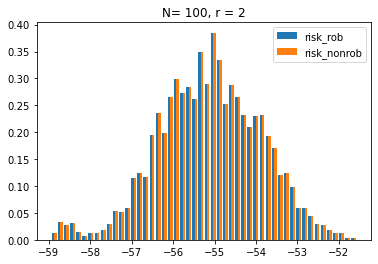

In [61]:
data1 = {'risk_rob':risk_rob, 'risk_nonrob': risk_nonrob}
dt1 = pd.DataFrame(data = data1)
plt.hist(dt1,density = True, bins = 50)
plt.legend(dt1.columns)
plt.title('N= 100, r = 2')
plt.savefig('mnews_N100_singpow2')

In [47]:
N = 50
r = phi_dot/(2*N)*scipy.stats.chi2.ppf(0.95, m-1)

0.40113272069413625

In [88]:
alpha0 = 0.9

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


17


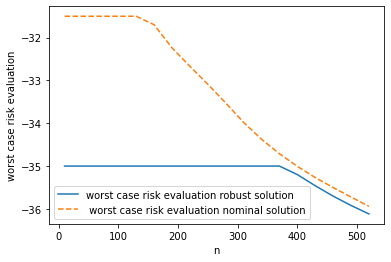

In [89]:
Nsize = np.arange(10,550,30)
L = len(Nsize)
wcrisk_rob = np.zeros(L)
wcrisk_nom = np.zeros(L)
for i in range(L):
    r = phi_dot/(2*Nsize[i])*scipy.stats.chi2.ppf(0.95, m-1)
    wcrisk_rob[i] = mnews_affine_riskmin(p,d,r,indices,par_mnews,phi_conj,np.array([1/(1-alpha0),0]),np.array([0,1]))[1]
    #res_nom = mnews_affine_riskmin(p,d,0,indices,par_mnews,phi_conj,np.array([1/(1-alpha0),0]),np.array([0,1]))[0]
    res_nom = non_robust_mnews_cut(d,p,alpha0,par_mnews, hf.h_cvar_eva)[0]
    print(i)
    wcrisk_nom[i] = robustcheck_riskmin(res_nom,d,r,p,alpha0,par_mnews,indices,hf.h_cvar_cut, phi.kb_cut)[0]
plt.plot(Nsize, wcrisk_rob, label = 'worst case risk evaluation robust solution')
plt.plot(Nsize, wcrisk_nom,'--', label = ' worst case risk evaluation nominal solution')
plt.xlabel('n')
plt.ylabel('worst case risk evaluation')
plt.legend()
plt.savefig('mnewline09.eps', format = 'eps')

In [67]:
wcrisk_nom

array([-31.10593062, -36.69789438, -39.82000113, -41.82312809,
       -43.21539317, -44.22368804, -45.03521223, -45.70832814,
       -46.28453965, -46.76737047, -47.17885114, -47.53474008,
       -47.84634598, -48.12387873, -48.37875871, -48.61514357,
       -48.83144136, -49.0285886 , -49.20922166, -49.37550247])

In [70]:
wcrisk_nom

array([-30.99999981, -31.6953039 , -34.67384768, -36.58156869,
       -37.97547648, -39.00677626, -39.84713145, -40.55532731,
       -41.15934815, -41.66171494, -42.08743627, -42.4537974 ,
       -42.7761138 , -43.07095412, -43.34422294, -43.59471783,
       -43.82103174, -44.02743876, -44.22153286, -44.40619444])

In [49]:
alpha0 = 0.4
res_cvar = mnews_affine_riskmin(p,d,r,indices,par_mnews,phi_conj,np.array([1/(1-alpha0),0]),np.array([0,1]))
print(res_cvar)

(array([7.92974414, 9.99999999, 8.        ]), array([-43.21907343]))


In [110]:
r

0.08022654413882725

In [112]:
multi_item_riskmin_cut(d,r,p,alpha0,par_mnews,hf.h_cv_eva, phi_func,hf.h_cvar_cut)

-28.28764341062629 [-82.13] 0
-17.860077358592193 [-41.17081987] 1
-20.053674903603074 [-36.26168582] 2
-33.695880412062635 [-35.37616262] 3
-33.98953902743207 [-35.23532476] 4
-35.00000086426414 [-34.99999535] 5


(array([7.00000068, 9.99999994, 7.20000141]), array([-34.99999535]), 5)

In [70]:
q_bwc = robustcheck_riskmin(res_cvar[0],d,r,p,alpha0,par_mnews,indices,hf.h_cvar_cut, phi.kb_cut)[1]
non_robust_mnews_uncertain(d,q_bwc,par,par_mnews, hf.h_cv_eva)

(array([10., 10., 10.]), array([-43.89014284]))

In [50]:
nomres_cvar = non_robust_mnews_cut(d,p,alpha0,par_mnews, hf.h_cvar_eva)
print(nomres_cvar)

(array([ 8., 10.,  8.]), array([-55.30979167]), 2)


In [58]:
print(nominal_risk(res_cvar[0],d,p,alpha0,par_mnews, hf.h_cvar_eva)[0])
print(nominal_risk(nomres_cvar[0],d,p,alpha0,par_mnews, hf.h_cvar_eva)[0])
[rbvalue_nom,qb_nom,q_nom] = robustcheck_riskmin(nomres_cvar[0],d,r,p,alpha0,par_mnews,indices,hf.h_cvar_cut, phi.kb_cut)
print(rbvalue_nom)

-55.23953575048689
-55.30979166663725
-43.21539316758306


In [115]:
q_wc = robustcheck_riskmin(nomres_cvar[0],d,r,p,alpha0,par_mnews,indices,hf.h_cvar_cut, phi.kb_cut)[2]
p_alt = 0.5*q_wc+0.5*p

In [116]:
np.random.seed(9)
prob = hr.hit_and_run(p_alt,phi.kb_eva,r,1,7000)

In [35]:
p

array([0.01190625, 0.0736875 , 0.00815625, 0.01190625, 0.0736875 ,
       0.00815625, 0.0238125 , 0.147375  , 0.0163125 , 0.01190625,
       0.0736875 , 0.00815625, 0.01190625, 0.0736875 , 0.00815625,
       0.0238125 , 0.147375  , 0.0163125 , 0.0079375 , 0.049125  ,
       0.0054375 , 0.0079375 , 0.049125  , 0.0054375 , 0.015875  ,
       0.09825   , 0.010875  ])

In [117]:
l = len(prob)
risk_rob = np.zeros(l)
risk_nonrob = np.zeros(l)
for i in range(l):
    risk_rob[i] = nominal_risk(res_cvar[0],d,prob[i],alpha0,par_mnews, hf.h_cv_eva)[0]
    risk_nonrob[i] = nominal_risk(nomres_cvar[0],d,prob[i],alpha0,par_mnews, hf.h_cv_eva)[0]

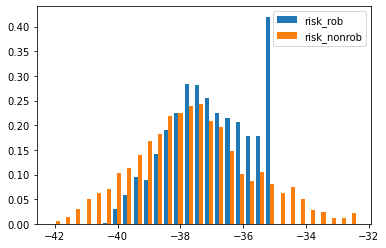

In [119]:
data1 = {'risk_rob':risk_rob, 'risk_nonrob': risk_nonrob}
dt1 = pd.DataFrame(data = data1)
plt.hist(dt1,density = True, bins = 30)
plt.legend(dt1.columns)
plt.savefig('mnewsN500alpha09')

In [88]:
quad_var = np.zeros(len(prob))
for i in range(len(prob)):
    quad_var[i] = np.sum(np.abs(prob[i]-p))
print(np.max(quad_var), np.min(quad_var),np.mean(quad_var))

0.538414480472252 0.045491807963701156 0.43958619810426663
